In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import sqlite3

In [173]:


food = pd.read_csv("hdx_hapi_food_security_ken.csv")
rain = pd.read_csv("hdx_hapi_rainfall_ken.csv")
price = pd.read_csv("wfp_food_prices_ken.csv")

In [ ]:
#monthy date variable(food security)
food['Date'] = pd.to_datetime(food['reference_period_start'])
food['Month'] = food['Date'].dt.to_period('M')

In [175]:
rain['Date'] = pd.to_datetime(rain['reference_period_start'])
rain['Month'] = rain['Date'].dt.to_period('M')

In [176]:
price['Date'] = pd.to_datetime(price['date'])
price['Month'] = price['Date'].dt.to_period('M')

In [177]:
food['County'] = (
    food['admin1_name']
    .astype(str)
    .str.strip()
)

In [186]:
rain['County'] = (
    rain['admin1_name']
    .astype(str)
    .str.strip()
)

In [179]:
price['County'] = (
    price['admin2']
    .astype(str)
    .str.strip()
)

In [180]:
#standardize county names
county_fix = {
    'Homabay':'Homa Bay',
    'Tana river':'Tana River',
    'West pokot':'West Pokot'
}

In [181]:
for df in [food, rain, price]:

    df['County'] = (
        df['County']
        .replace(county_fix)
    )

In [187]:
#check for overlap
food_counties = set(food['County'].unique())
rain_counties = set(rain['County'].unique())
price_counties = set(price['County'].unique())

print("Food counties:", len(food_counties))
print("Rain counties:", len(rain_counties))
print("Price counties:", len(price_counties))

print("Food ∩ Rain:",
      len(food_counties.intersection(rain_counties)))

print("Food ∩ Price:",
      len(food_counties.intersection(price_counties)))

Food counties: 30
Rain counties: 47
Price counties: 28
Food ∩ Rain: 29
Food ∩ Price: 20


In [183]:
print(rain['provider_admin1_name'].nunique())
print(rain['provider_admin1_name'].unique()[:20])

1
<StringArray>
['Not provided']
Length: 1, dtype: str


In [184]:
print(rain['admin1_name'].nunique())
print(rain['admin1_name'].unique()[:20])

47
<StringArray>
[       'Nyeri',   'Tana River',     'Marsabit',      'Nairobi',
        'Wajir',     'Homa Bay',      'Turkana',     'Kakamega',
       'Kiambu',    'Kirinyaga',     'Murang'a',    'Nyandarua',
       'Kilifi',        'Kwale',         'Lamu',      'Mombasa',
 'Taita Taveta',         'Embu',       'Isiolo',        'Kitui']
Length: 20, dtype: str


In [188]:
food_counties = set(food['County'].dropna().unique())
rain_counties = set(rain['County'].dropna().unique())
price_counties = set(price['County'].dropna().unique())

print("Missing in Rain:")
print(sorted(food_counties - rain_counties))

print("\nMissing in Prices:")
print(sorted(food_counties - price_counties))

Missing in Rain:
[]

Missing in Prices:
['Elgeyo-Marakwet', 'Embu', 'Homa Bay', 'Kiambu', 'Laikipia', 'Lamu', 'Meru', 'Migori', 'Narok', 'Tharaka-Nithi']


In [189]:
food['ipc_phase'].value_counts().sort_index()

ipc_phase
1      572
2      572
3      572
3+     572
4      572
5      572
all    572
Name: count, dtype: int64

In [190]:
food_sec = food[
    food['ipc_phase'].astype(str).isin(['3','4','5'])
].copy()

In [191]:
food_monthly = (
    food_sec
    .groupby(['Month','County'])
    .agg({
        'population_in_phase':'sum',
        'population_fraction_in_phase':'mean'
    })
    .reset_index()
)

food_monthly.rename(
    columns={
        'population_in_phase':'IPC3plus_Pop',
        'population_fraction_in_phase':'IPC3plus_Fraction'
    },
    inplace=True
)

food_monthly.head()

,Month,County,IPC3plus_Pop,IPC3plus_Fraction
0,2021-02,Baringo,66678,0.033333
1,2021-02,Embu,0,0.000000
2,2021-02,Garissa,126203,0.050000
3,2021-02,Isiolo,40200,0.050000
4,2021-02,Kajiado,55892,0.016667


In [192]:
food_monthly.shape

(516, 4)

In [193]:
maize_list = [
    'Maize',
    'Maize (white)',
    'Maize (white, dry)',
    'Maize flour',
    'Maize flour (white)'
]

maize = price[
    price['commodity'].isin(maize_list)
].copy()

In [194]:
maize_monthly = (
    maize
    .groupby(['Month','County'])['price']
    .median()
    .reset_index()
)

maize_monthly.rename(
    columns={'price':'Maize_Price'},
    inplace=True
)

maize_monthly.head()

,Month,County,Maize_Price
0,2006-01,Kisumu,667.420
1,2006-01,Kitui,17.000
2,2006-01,Mandera,30.000
3,2006-01,Marsabit,21.000
4,2006-01,Mombasa,748.065


In [195]:
maize_monthly.shape

(2379, 3)

In [196]:
bean_list = [
    'Beans',
    'Beans (dry)',
    'Beans (rosecoco)',
    'Beans (dolichos)',
    'Beans (kidney)',
    'Beans (yellow)'
]

beans = price[
    price['commodity'].isin(bean_list)
].copy()

In [197]:
bean_monthly = (
    beans
    .groupby(['Month','County'])['price']
    .median()
    .reset_index()
)

bean_monthly.rename(
    columns={'price':'Bean_Price'},
    inplace=True
)

bean_monthly.head()

,Month,County,Bean_Price
0,2006-01,Kisumu,2019.805
1,2006-01,Kitui,39.000
2,2006-01,Mombasa,1639.815
3,2006-01,Nairobi,1608.655
4,2006-01,Uasin Gishu,1422.425


In [198]:
bean_monthly.shape

(1740, 3)

In [199]:
rain_monthly = (
    rain
    .groupby(['Month','County'])
    .agg({
        'rainfall':'mean',
        'rainfall_anomaly_pct':'mean'
    })
    .reset_index()
)

rain_monthly.rename(
    columns={
        'rainfall':'Rainfall',
        'rainfall_anomaly_pct':'Rainfall_Anomaly'
    },
    inplace=True
)

rain_monthly.head()

,Month,County,Rainfall,Rainfall_Anomaly
0,2022-01,Homa Bay,170.151643,143.502722
1,2022-01,Kakamega,113.527985,112.529765
2,2022-01,Marsabit,87.816744,117.099478
3,2022-01,Nairobi,112.606832,85.309015
4,2022-01,Nyeri,115.638046,90.446905


In [200]:
rain_monthly.shape

(900, 4)

In [201]:
food_security_df = (
    food_monthly
    .merge(
        maize_monthly,
        on=['Month','County'],
        how='left'
    )
)

In [202]:
food_security_df.shape

(516, 5)

In [203]:
food_security_df.isnull().sum()

Month                  0
County                 0
IPC3plus_Pop           0
IPC3plus_Fraction      0
Maize_Price          412
dtype: int64

In [204]:
food_security_df = (
    food_security_df
    .merge(
        bean_monthly,
        on=['Month','County'],
        how='left'
    )
)

In [205]:
food_security_df.isnull().sum()

Month                  0
County                 0
IPC3plus_Pop           0
IPC3plus_Fraction      0
Maize_Price          412
Bean_Price           415
dtype: int64

In [206]:
food_security_df = (
    food_security_df
    .merge(
        rain_monthly,
        on=['Month','County'],
        how='left'
    )
)

In [207]:
food_security_df.shape

(516, 8)

In [208]:
food_security_df.isnull().sum()

Month                  0
County                 0
IPC3plus_Pop           0
IPC3plus_Fraction      0
Maize_Price          412
Bean_Price           415
Rainfall             352
Rainfall_Anomaly     352
dtype: int64

In [209]:
food_security_df[
    food_security_df['Rainfall'].isna()
]['County'].value_counts()

County
Baringo            18
Embu               18
Garissa            18
Isiolo             18
Kajiado            18
Kilifi             18
Kitui              18
Kwale              18
Laikipia           18
Lamu               18
Makueni            18
Mandera            18
Meru               18
Narok              18
Samburu            18
Taita Taveta       18
Tharaka-Nithi      18
West Pokot         18
Marsabit            4
Nyeri               4
Tana River          4
Turkana             4
Wajir               4
Elgeyo-Marakwet     2
Kiambu              2
Machakos            2
Migori              2
Name: count, dtype: int64

In [210]:
food_security_df[
    food_security_df['Maize_Price'].isna()
]['County'].value_counts()

County
Embu               22
Kajiado            22
Kilifi             22
Kwale              22
Laikipia           22
Lamu               22
Meru               22
Narok              22
Samburu            22
Taita Taveta       22
Tana River         22
Tharaka-Nithi      22
Wajir              19
Kitui              18
Isiolo             18
Marsabit           16
Mandera            14
Nyeri              13
West Pokot         13
Baringo            12
Makueni             9
Turkana             5
Elgeyo-Marakwet     2
Homa Bay            2
Kiambu              2
Machakos            2
Migori              2
Garissa             1
Name: count, dtype: int64

In [211]:
food_security_df[
    food_security_df['Bean_Price'].isna()
]['County'].value_counts()

County
Embu               22
Kilifi             22
Kwale              22
Laikipia           22
Lamu               22
Meru               22
Narok              22
Samburu            22
Taita Taveta       22
Tana River         22
Tharaka-Nithi      22
Kitui              19
Wajir              19
Makueni            18
Isiolo             18
Nyeri              17
Marsabit           16
Kajiado            14
Mandera            13
Baringo            11
West Pokot         11
Turkana             5
Elgeyo-Marakwet     2
Homa Bay            2
Kiambu              2
Machakos            2
Migori              2
Kisumu              2
Name: count, dtype: int64

In [212]:
food_monthly.groupby('County')['Month'].agg(['min','max','count'])

,min,max,count
County,,,
Baringo,2021-02,2026-04,22
Elgeyo-Marakwet,2023-02,2023-03,2
Embu,2021-02,2026-04,22
Garissa,2021-02,2026-04,22
Homa Bay,2023-02,2023-03,2
Isiolo,2021-02,2026-04,22
Kajiado,2021-02,2026-04,22
Kiambu,2023-02,2023-03,2
Kilifi,2021-02,2026-04,22


In [213]:
sorted(food_monthly['Month'].unique())

[Period('2021-02', 'M'),
 Period('2021-03', 'M'),
 Period('2021-07', 'M'),
 Period('2021-11', 'M'),
 Period('2022-02', 'M'),
 Period('2022-03', 'M'),
 Period('2022-07', 'M'),
 Period('2022-10', 'M'),
 Period('2023-02', 'M'),
 Period('2023-03', 'M'),
 Period('2023-07', 'M'),
 Period('2023-10', 'M'),
 Period('2024-02', 'M'),
 Period('2024-04', 'M'),
 Period('2024-07', 'M'),
 Period('2024-10', 'M'),
 Period('2025-02', 'M'),
 Period('2025-04', 'M'),
 Period('2025-07', 'M'),
 Period('2025-10', 'M'),
 Period('2026-01', 'M'),
 Period('2026-04', 'M')]

In [214]:
# remove counties with 2 observations
county_counts = food_security_df['County'].value_counts()

valid_counties = county_counts[county_counts >= 10].index

food_security_df = food_security_df[
    food_security_df['County'].isin(valid_counties)
].copy()

In [215]:
food_security_df['County'].value_counts()

County
Baringo          22
Embu             22
Garissa          22
Isiolo           22
Kajiado          22
Kilifi           22
Kitui            22
Kwale            22
Laikipia         22
Lamu             22
Makueni          22
Mandera          22
Meru             22
Narok            22
Nyeri            22
Samburu          22
Taita Taveta     22
Tana River       22
Tharaka-Nithi    22
Turkana          22
Wajir            22
West Pokot       22
Marsabit         20
Name: count, dtype: int64

In [216]:
for col in ['Maize_Price', 'Bean_Price']:

    food_security_df[col] = (
        food_security_df[col]
        .fillna(
            food_security_df.groupby('Month')[col]
            .transform('median')
        )
    )

In [217]:
for col in ['Rainfall', 'Rainfall_Anomaly']:

    food_security_df[col] = (
        food_security_df[col]
        .fillna(
            food_security_df.groupby('County')[col]
            .transform('median')
        )
    )

In [218]:
food_security_df.isnull().sum()

Month                0
County               0
IPC3plus_Pop         0
IPC3plus_Fraction    0
Maize_Price          0
Bean_Price           0
Rainfall             0
Rainfall_Anomaly     0
dtype: int64

In [219]:
food_security_df.shape

(504, 8)

In [220]:
food_security_df.info()

<class 'pandas.DataFrame'>
Index: 504 entries, 0 to 515
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype    
---  ------             --------------  -----    
 0   Month              504 non-null    period[M]
 1   County             504 non-null    str      
 2   IPC3plus_Pop       504 non-null    int64    
 3   IPC3plus_Fraction  504 non-null    float64  
 4   Maize_Price        504 non-null    float64  
 5   Bean_Price         504 non-null    float64  
 6   Rainfall           504 non-null    float64  
 7   Rainfall_Anomaly   504 non-null    float64  
dtypes: float64(5), int64(1), period[M](1), str(1)
memory usage: 35.4 KB


In [221]:
#create a copy
security_df = food_security_df.copy()


In [222]:
security_df.to_excel(
    "Kenya_Food_Security_Final.xlsx",
    index=False
)

In [223]:
import os
os.getcwd()

'c:\\Users\\HP\\Desktop\\finalcapstone\\FINALCAPSTONE'

In [224]:
security_df.to_csv(
    "Kenya_Food_Security_Final.csv",
    index=False
)

In [227]:
security_df.dtypes

Month                period[M]
County                     str
IPC3plus_Pop             int64
IPC3plus_Fraction      float64
Maize_Price            float64
Bean_Price             float64
Rainfall               float64
Rainfall_Anomaly       float64
dtype: object

In [228]:
security_df_sql = security_df.copy()

security_df_sql['Month'] = (
    security_df_sql['Month']
    .astype(str)
)

In [229]:
security_df_sql.dtypes

Month                    str
County                   str
IPC3plus_Pop           int64
IPC3plus_Fraction    float64
Maize_Price          float64
Bean_Price           float64
Rainfall             float64
Rainfall_Anomaly     float64
dtype: object

In [230]:
import sqlite3

conn = sqlite3.connect("food_security.db")

security_df_sql.to_sql(
    "food_security_final",
    conn,
    if_exists="replace",
    index=False
)

504

In [231]:
pd.read_sql(
    "SELECT * FROM food_security_final LIMIT 5",
    conn
)

,Month,County,IPC3plus_Pop,IPC3plus_Fraction,Maize_Price,Bean_Price,Rainfall,Rainfall_Anomaly
0,2021-02,Baringo,66678,0.033333,1379.1675,8100.0,184.792230,122.517826
1,2021-02,Embu,0,0.000000,1379.1675,7123.5,114.865267,106.617029
2,2021-02,Garissa,126203,0.050000,1379.1675,7863.0,65.682315,84.940267
3,2021-02,Isiolo,40200,0.050000,50.0000,102.5,28.278381,96.034848
4,2021-02,Kajiado,55892,0.016667,1379.1675,7123.5,61.415497,120.768651


In [234]:
security_df_sql.to_excel(
    "Kenya_Food_Security_Final.xlsx",
    index=False
)

In [232]:
security_df_sql.to_csv(
    "Kenya_Food_Security_Final.csv",
    index=False
)

In [235]:
security_df.shape
security_df.dtypes

Month                period[M]
County                     str
IPC3plus_Pop             int64
IPC3plus_Fraction      float64
Maize_Price            float64
Bean_Price             float64
Rainfall               float64
Rainfall_Anomaly       float64
dtype: object

In [236]:
security_df = (
    security_df
    .sort_values(['County','Month'])
    .reset_index(drop=True)
)

In [237]:
security_df['Lag1'] = (
    security_df
    .groupby('County')['IPC3plus_Pop']
    .shift(1)
)

security_df['Lag2'] = (
    security_df
    .groupby('County')['IPC3plus_Pop']
    .shift(2)
)

security_df['Lag4'] = (
    security_df
    .groupby('County')['IPC3plus_Pop']
    .shift(4)
)

In [238]:
security_df['Rolling2'] = (
    security_df
    .groupby('County')['IPC3plus_Pop']
    .transform(lambda x: x.rolling(2).mean())
)

security_df['Rolling4'] = (
    security_df
    .groupby('County')['IPC3plus_Pop']
    .transform(lambda x: x.rolling(4).mean())
)

In [239]:
import numpy as np

security_df['Month_Num'] = security_df['Month'].dt.month

security_df['Month_Sin'] = np.sin(
    2*np.pi*security_df['Month_Num']/12
)

security_df['Month_Cos'] = np.cos(
    2*np.pi*security_df['Month_Num']/12
)

In [240]:
security_df = security_df.dropna().reset_index(drop=True)

In [241]:
security_df.isnull().sum()

Month                0
County               0
IPC3plus_Pop         0
IPC3plus_Fraction    0
Maize_Price          0
Bean_Price           0
Rainfall             0
Rainfall_Anomaly     0
Lag1                 0
Lag2                 0
Lag4                 0
Rolling2             0
Rolling4             0
Month_Num            0
Month_Sin            0
Month_Cos            0
dtype: int64

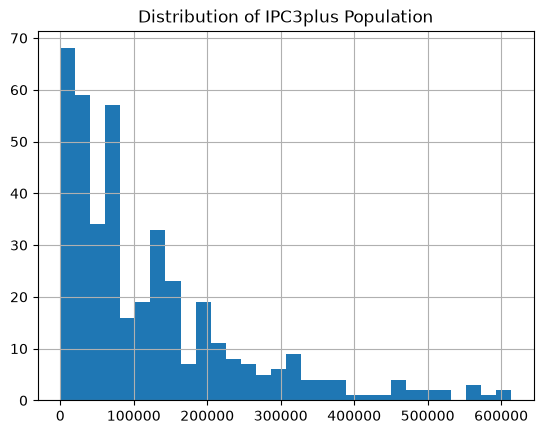

In [242]:
import matplotlib.pyplot as plt

security_df['IPC3plus_Pop'].hist(bins=30)

plt.title('Distribution of IPC3plus Population')
plt.show()

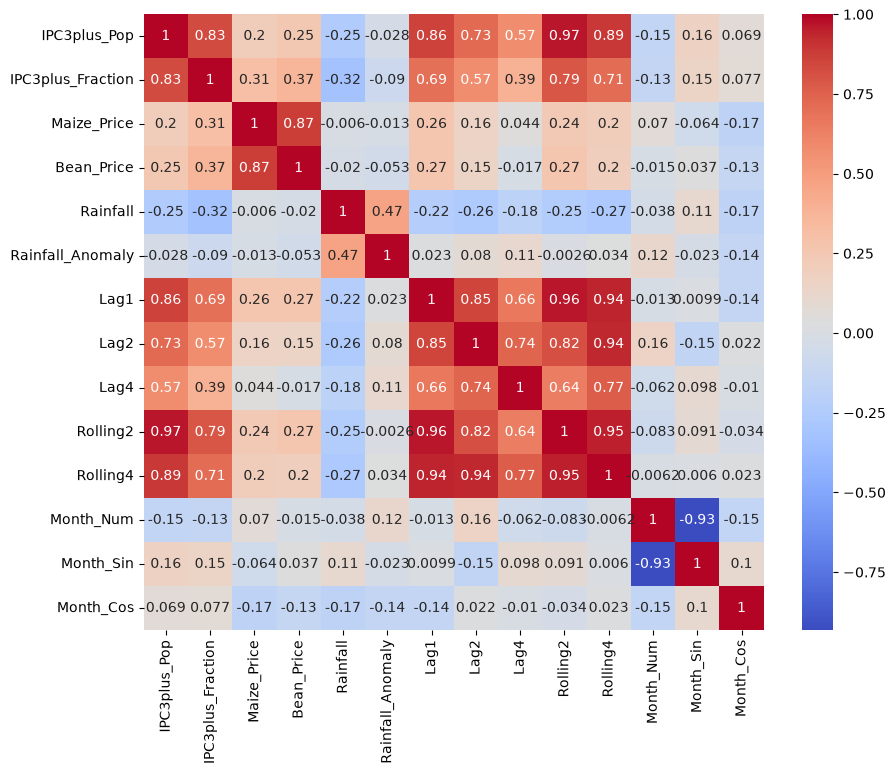

In [243]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = security_df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.show()

In [244]:
train = security_df[
    security_df['Month'] < '2025-01'
]

test = security_df[
    security_df['Month'] >= '2025-01'
]

In [245]:
train.shape
test.shape

(138, 16)

In [246]:
features = [
    'IPC3plus_Fraction',
    'Maize_Price',
    'Bean_Price',
    'Rainfall',
    'Rainfall_Anomaly',
    'Lag1',
    'Lag2',
    'Lag4',
    'Rolling2',
    'Rolling4',
    'Month_Sin',
    'Month_Cos'
]

target = 'IPC3plus_Pop'

In [248]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [251]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(274, 12)
(274,)
(138, 12)
(138,)


In [249]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

naive_pred = test['Lag1']

mae = mean_absolute_error(
    y_test,
    naive_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        naive_pred
    )
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 34308.13043478261
RMSE: 55352.32436526655


In [252]:
national = (
    security_df
    .groupby('Month')
    .agg({
        'IPC3plus_Pop':'sum'
    })
    .reset_index()
)

In [253]:
national['Month'] = national['Month'].dt.to_timestamp()

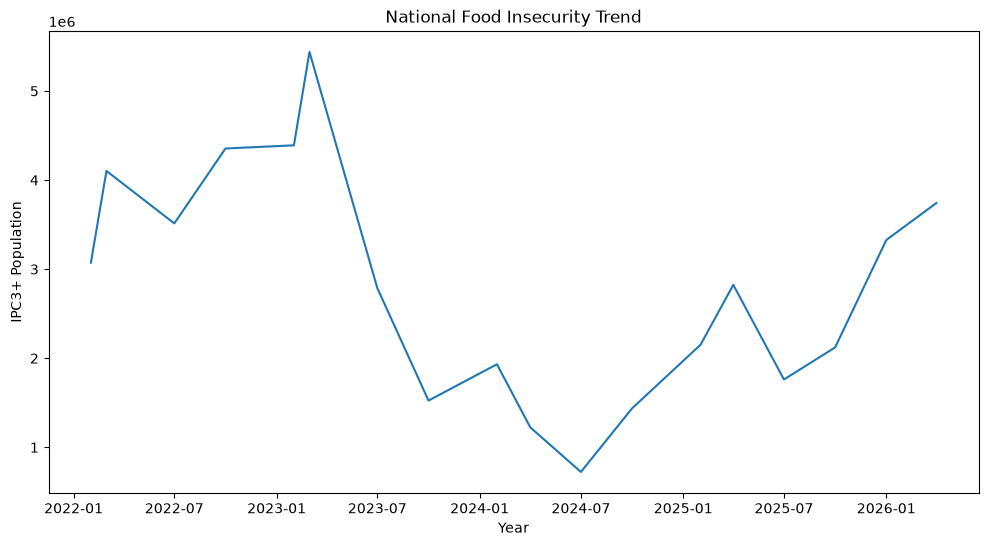

In [254]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    national['Month'],
    national['IPC3plus_Pop']
)

plt.title('National Food Insecurity Trend')
plt.xlabel('Year')
plt.ylabel('IPC3+ Population')

plt.show()

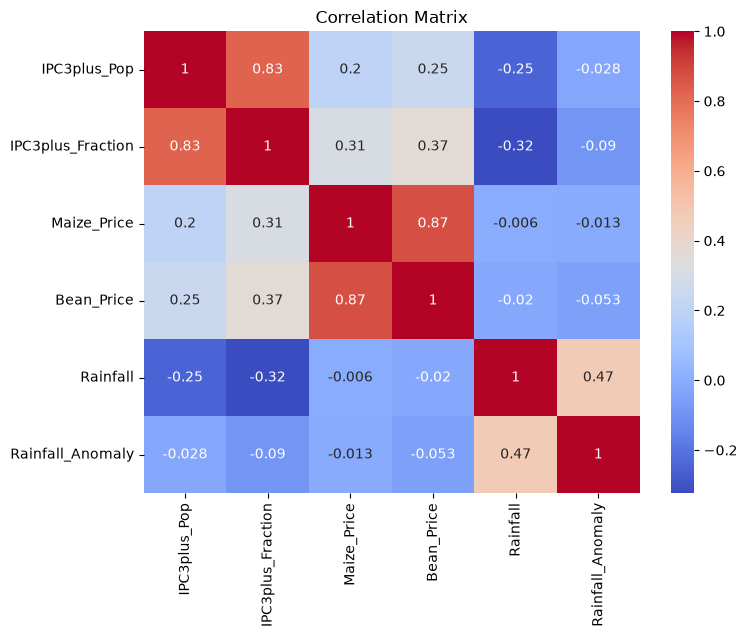

In [255]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [
    'IPC3plus_Pop',
    'IPC3plus_Fraction',
    'Maize_Price',
    'Bean_Price',
    'Rainfall',
    'Rainfall_Anomaly'
]

corr = security_df[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

In [256]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

ModuleNotFoundError: No module named 'xgboost'